In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torchsummary
from IPython.display import clear_output
from matplotlib import pyplot as plt
from matplotlib.pyplot import figure
import numpy as np
import os


device = "cuda:0" if torch.cuda.is_available() else "cpu"

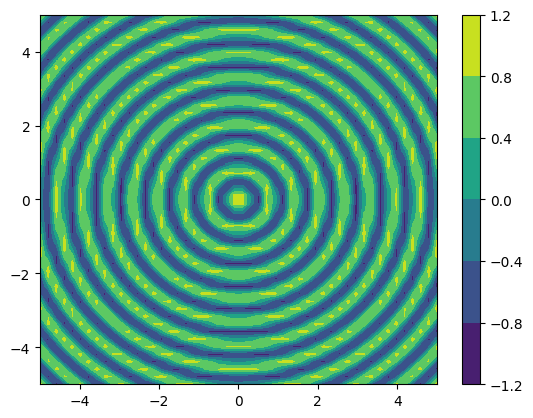

In [18]:
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 50)
y = np.linspace(-5, 5, 50)
X, Y = np.meshgrid(x, y)
Z = np.sin(np.sqrt(X**2 + Y**2)*10)

plt.contourf(X, Y, Z, levels=5)
plt.colorbar()
plt.show()


In [3]:
n_features = 2
n_objects = 300
batch_size = 10
num_steps = 43
np.random.seed(42)

# Let it be the *true* weights vector
w_true = np.random.normal(size=(n_features, ))

X = np.random.uniform(-5, 5, (n_objects, n_features))

# For different scales of features. In case of 3 features the code is equal to the commented line below
# X *= np.arange([1, 3, 5])[None, :]
X *= (np.arange(n_features) * 2 + 1)[np.newaxis, :] 

# Here comes the *true* target vector
Y = X.dot(w_true) + np.random.normal(0, 1, n_objects)

In [6]:
A, B = np.meshgrid(np.linspace(-2, 2, 10), np.linspace(-2, 2, 10))

levels = np.empty_like(A)
for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        w_tmp = np.array([A[i, j], B[i, j]])
        levels[i, j] = np.mean(np.power(np.dot(X, w_tmp) - Y, 2))


In [7]:
levels

array([[336.59798098, 315.63499414, 298.31713748, 284.64441098,
        274.61681466, 268.23434851, 265.49701253, 266.40480672,
        270.95773108, 279.15578561],
       [221.68475168, 201.3070899 , 184.57455829, 171.48715684,
        162.04488557, 156.24774447, 154.09573354, 155.58885278,
        160.72710219, 169.51048178],
       [137.09166137, 117.29932464, 101.15211807,  88.65004168,
         79.79309546,  74.58127941,  73.01459353,  75.09303783,
         80.81661229,  90.18531692],
       [ 82.81871004,  63.61169835,  48.04981684,  36.1330655 ,
         27.86144433,  23.23495333,  22.25359251,  24.91736185,
         31.22626136,  41.18029105],
       [ 58.86589768,  40.24421105,  25.26765459,  13.9362283 ,
          6.24993218,   2.20876623,   1.81273046,   5.06182485,
         11.95604941,  22.49540415],
       [ 65.2332243 ,  47.19686272,  32.80563131,  22.05953007,
         14.95855901,  11.50271811,  11.69200738,  15.52642683,
         23.00597645,  34.13065623],
       [10

In [9]:
first = torch.zeros(5, requires_grad=True)
torch.tensor(np.arange(5), dtype=torch.float32, requires_grad=True)

tensor([0., 1., 2., 3., 4.], requires_grad=True)

In [10]:
first

tensor([0., 0., 0., 0., 0.], requires_grad=True)

In [1]:
import torch

# Инициализируем переменную x с requires_grad=True
x = torch.tensor([0.0], requires_grad=True)  # Стартовое значение x = 0.0

# Задаем параметры
learning_rate = 0.1
num_steps = 50

# Оптимизация с использованием градиентного спуска
for step in range(num_steps):
    # Вычисляем значение функции f(x) = (x - 3)^2
    y = (x - 3) ** 2

    # Вычисляем градиенты
    y.backward()

    # Обновляем x с учетом градиента
    with torch.no_grad():  # Отключаем отслеживание градиентов для обновления параметров
        x -= learning_rate * x.grad  # Обновляем x
        x.grad.zero_()  # Обнуляем градиент для следующей итерации

    # Вывод промежуточного результата
    if step % 10 == 0:
        print(f"Step {step}: x = {x.item()}, y = {y.item()}")

# Финальный результат
print(f"Optimized x: {x.item()}, Minimum value of y: {(x - 3).pow(2).item()}")


Step 0: x = 0.6000000238418579, y = 9.0
Step 10: x = 2.7423019409179688, y = 0.10376295447349548
Step 20: x = 2.97232985496521, y = 0.001196303521282971
Step 30: x = 2.9970288276672363, y = 1.3792653589916881e-05
Step 40: x = 2.999680995941162, y = 1.5910069350866252e-07
Optimized x: 2.999957323074341, Minimum value of y: 1.8213199837191496e-09


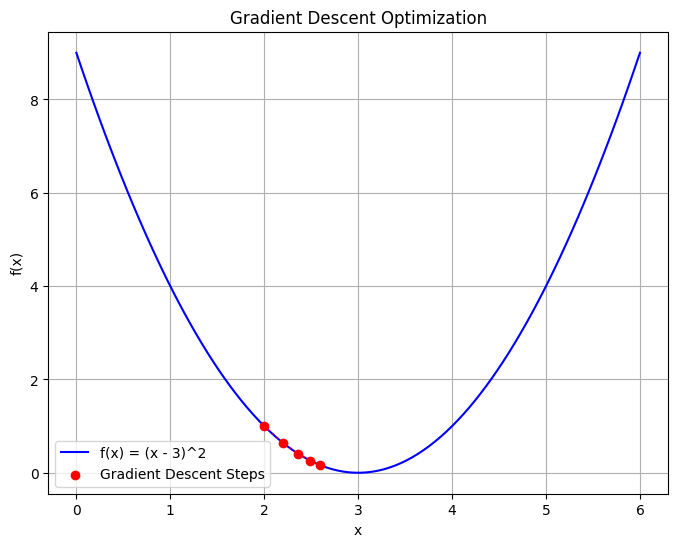

In [6]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Инициализируем переменную x с requires_grad=True
x = torch.tensor([2.0], requires_grad=True)  # Стартовое значение x = 0.0

# Задаем параметры
learning_rate = 0.1
num_steps = 5

# Для визуализации
x_history = []
y_history = []

# Оптимизация с использованием градиентного спуска
for step in range(num_steps):
    # Вычисляем значение функции f(x) = (x - 3)^2
    y = (x - 3) ** 2

    # Сохраняем историю для визуализации
    x_history.append(x.item())
    y_history.append(y.item())

    # Вычисляем градиенты
    y.backward()

    # Обновляем x с учетом градиента
    with torch.no_grad():  # Отключаем отслеживание градиентов для обновления параметров
        x -= learning_rate * x.grad  # Обновляем x
        x.grad.zero_()  # Обнуляем градиент для следующей итерации

# Построение графика функции и траектории
x_vals = np.linspace(0, 6, 100)  # Диапазон для x
y_vals = (x_vals - 3) ** 2  # Значения функции

plt.figure(figsize=(8, 6))
plt.plot(x_vals, y_vals, label="f(x) = (x - 3)^2", color="blue")
plt.scatter(x_history, y_history, color="red", label="Gradient Descent Steps", zorder=5)
plt.plot(x_history, y_history, color="red", linestyle="dotted", alpha=0.6)
plt.title("Gradient Descent Optimization")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid()
plt.show()

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Определяем модель
class Model(nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        self.linear = nn.Linear(10, 5)  # Полносвязный слой (вход: 10, выход: 5)
    
    def forward(self, x):
        return F.relu(self.linear(x))  # Прямой проход через слой с ReLU активацией

# Инициализация модели
model = Model()
print(model)


Model(
  (linear): Linear(in_features=10, out_features=5, bias=True)
)


In [13]:
import torch
import torch.nn as nn

# Полносвязный слой: 4 входа, 2 выхода
linear = nn.Linear(4, 2)

# Входные данные (2 примера, каждый с размерностью 4)
input_data = torch.tensor([[1.0, 2.0, 3.0, 4.0],
                           [5.0, 6.0, 7.0, 8.0]])

# Прямой проход через слой
output = linear(input_data)

print("Output:", output)


Output: tensor([[ 0.2349, -0.7596],
        [ 2.0346, -1.6184]], grad_fn=<AddmmBackward0>)


In [14]:
linear.weight

Parameter containing:
tensor([[ 0.3096,  0.0366,  0.2618, -0.1580],
        [ 0.1853, -0.1966,  0.1886, -0.3920]], requires_grad=True)

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim

# Генерация данных
x = torch.rand(100, 1) * 10  # Входы: от 0 до 10
y = 2.5 * x + 1.5 + torch.randn(100, 1)  # Истинная зависимость с шумом

# Модель линейной регрессии
model = nn.Linear(1, 1)  # Один вход, один выход

# Функция потерь и оптимизатор
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Обучение модели
for epoch in range(500):
    y_pred = model(x)
    loss = criterion(y_pred, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# Печать итогового результата
print("Вес и смещение:", model.weight.item(), model.bias.item())


Вес и смещение: 2.5100390911102295 1.4398571252822876


In [19]:
torch.rand(10, 2)  # Входы: от 0 до 10


tensor([[0.1689, 0.8515],
        [0.7731, 0.9289],
        [0.1930, 0.4855],
        [0.8821, 0.3588],
        [0.3163, 0.0260],
        [0.5418, 0.9642],
        [0.6730, 0.9459],
        [0.9573, 0.6299],
        [0.0263, 0.7192],
        [0.0942, 0.1131]])